## Fraud Detection on PaySim Mobile Money Transactions Using Machine Learning

### Problem Statement
Mobile money platforms have made financial transactions faster and more accessible, but they have also increased the risk of fraud such as unauthorized transfers and manipulated transactions.

Rule-based fraud detection systems are often unable to detect complex and changing fraud patterns. Because of this, a more adaptive, data-driven approach is needed to improve detection accuracy.

This study develops a machine learning-based fraud detection system using the PaySim dataset and compares the performance of Random Forest and XGBoost in identifying fraudulent mobile money transactions.

### The Dataset

Due to the inherently private nature of financial transactions, publicly available datasets are typically synthetic. One commonly used dataset is the PaySim Synthetic Mobile Money Dataset. This dataset simulates realistic mobile money transactions with injected malicious behavior similar to fraudulent activities.

The dataset includes the following key features:

`step` – Time unit representing hours in the simulation <br>
`type` – Type of transaction (CASH-IN, CASH-OUT, TRANSFER, PAYMENT, DEBIT) <br>
`amount` – Transaction amount in local currency <br>
`nameOrig` – Sender account identifier <br>
`oldbalanceOrg` – Sender balance before the transaction <br>
`newbalanceOrig` – Sender balance after the transaction <br>
`nameDest` – Receiver account identifier <br>
`oldbalanceDest` – Receiver balance before the transaction <br>
`newbalanceDest` – Receiver balance after the transaction <br>
`isFraud` – Target variable indicating fraudulent transactions <br>
`isFlaggedFraud` – Indicator of transactions flagged as potentially suspicious by the system <br>

The dataset is highly imbalanced, where fraudulent transactions represent only a small fraction of the total data.

**Note**
Transactions which are detected as fraud are cancelled, so for fraud detection these columns (oldbalanceOrg, newbalanceOrig, oldbalanceDest, newbalanceDest ) must not be used.

*Reference: Lopez-Rojas, E. A., Elmir, A., & Axelsson, S. (2016). PaySim: A financial mobile money simulator for fraud detection. In Proceedings of the 28th European Modeling and Simulation Symposium (EMSS), Larnaca, Cyprus.*

### Methodology/Approach
The study wil follow a supervised machine learning pipeline: <br>
I. Data Preprocessing <br>
II. Exploratory Data Analysis <br>
III. Feature Engineering <br>
IV. Model Development <br>
 -   Random Forest Classification <br>
 -   XGBoost Classification <br>

V. Model Evaluation (Best Model) <br>
VI. Threshold Tuning <br>
VII. Batch Inference


#### I. Data Preprocessing

##### *Import libraries*

In [1]:
# Import libraries
import pandas as pd

# Load the dataset
df = pd.read_csv("gs://paysim_mobile_money/raw_dataset/paysim_dataset.csv")
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [2]:
# Drop unnecessecary columns
df.drop(["oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest", "isFlaggedFraud"], axis=1, inplace=True)

##### *Data Transformation*

In [3]:
# Add new features: hour_of_day and day_of_week
df["hour_of_day"] = df["step"] % 24
df["day_of_week"] = ((df["step"] - 1) // 24) % 7

##### *Data Splitting*

In [4]:
from sklearn.model_selection import train_test_split

"""
The whole dataset is propoprtioned to 
- ML Dataset two-thirds of the whole dataset (~ 4 million rows) will be used for training and cross validation
- Remaining one-third (~ 2 million rows) will be used for final test of the model  as well as model inference and  Power BI reporting
"""

df_model, df_dashboard = train_test_split(
    df,
    test_size=0.33,
    random_state=2023,
    stratify=df["isFraud"]
)

#### II. Exploratory Data Analysis

##### *Import libraries*

In [5]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import math

##### *Dataset Overview*

In [6]:
# Check datatypes
df_model.info()

<class 'pandas.DataFrame'>
Index: 4262955 entries, 6099574 to 6331260
Data columns (total 8 columns):
 #   Column       Dtype  
---  ------       -----  
 0   step         int64  
 1   type         str    
 2   amount       float64
 3   nameOrig     str    
 4   nameDest     str    
 5   isFraud      int64  
 6   hour_of_day  int64  
 7   day_of_week  int64  
dtypes: float64(1), int64(4), str(3)
memory usage: 409.6 MB


In [7]:
# Check for null values
df.isnull().sum()

step           0
type           0
amount         0
nameOrig       0
nameDest       0
isFraud        0
hour_of_day    0
day_of_week    0
dtype: int64

In [8]:
# Quick statistical summary
df_model.describe()

,step,amount,isFraud,hour_of_day,day_of_week
count,4.262955e+06,4.262955e+06,4.262955e+06,4.262955e+06,4.262955e+06
mean,2.434127e+02,1.798055e+05,1.290889e-03,1.532190e+01,2.477237e+00
std,1.423450e+02,5.981603e+05,3.590574e-02,4.321103e+00,2.166255e+00
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338388e+04,0.000000e+00,1.200000e+01,1.000000e+00
50%,2.390000e+02,7.492616e+04,0.000000e+00,1.600000e+01,2.000000e+00
75%,3.350000e+02,2.087145e+05,0.000000e+00,1.900000e+01,5.000000e+00
max,7.430000e+02,9.244552e+07,1.000000e+00,2.300000e+01,6.000000e+00


##### *Understand the distribution*

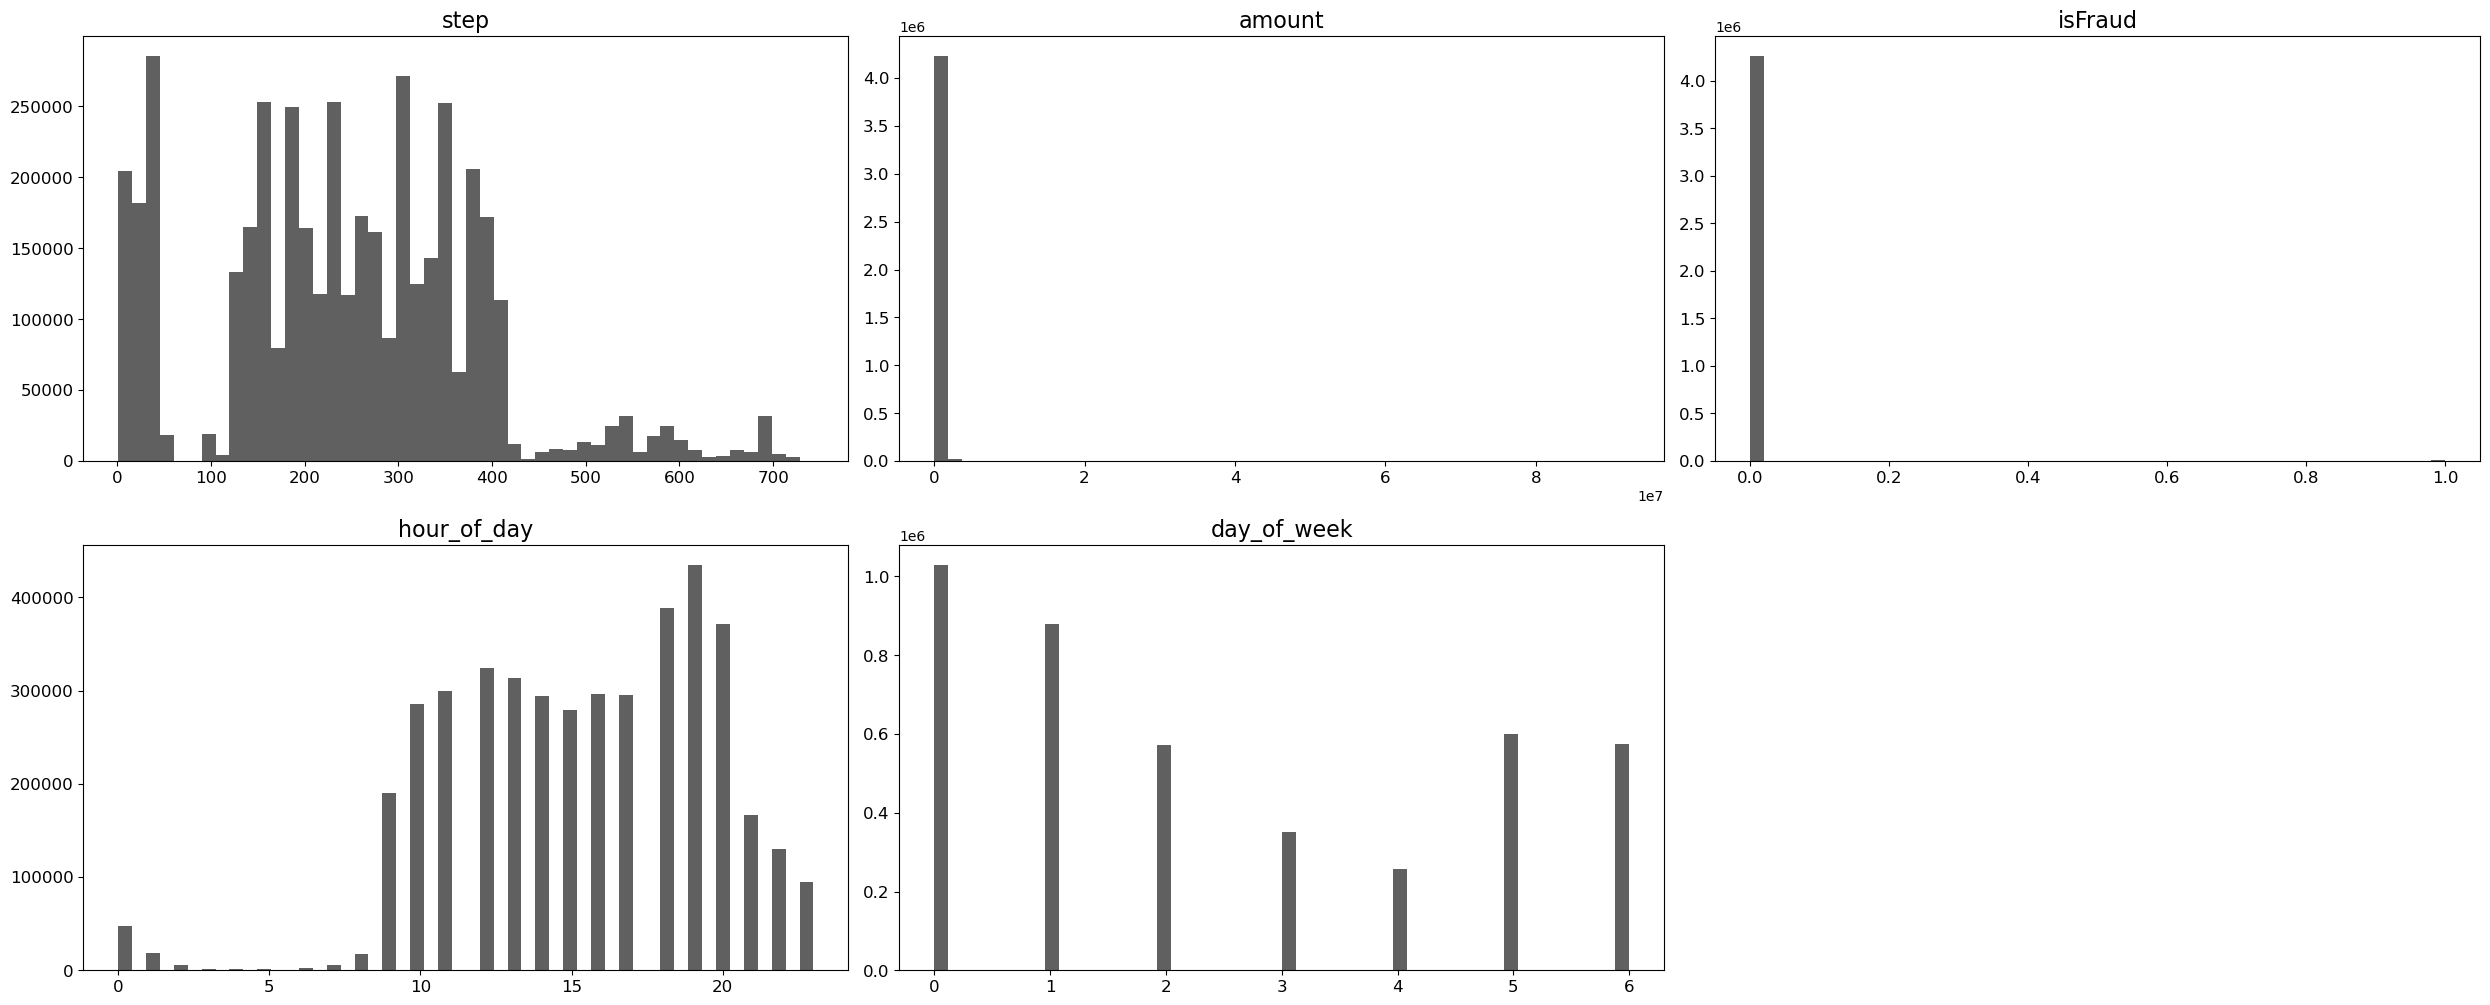

In [9]:
n_cols = 3
n_rows = math.ceil(len(df_model.columns) / n_cols)

axes = df_model.hist(
    bins=50,
    figsize=(25, 15),
    layout=(n_rows, n_cols),
    color='#606060'
)

for ax in axes.flatten():
    if ax is not None:
        ax.title.set_fontsize(16)
        ax.xaxis.label.set_size(18)
        ax.yaxis.label.set_size(18)
        ax.tick_params(axis='both', labelsize=12)
        ax.grid(False)

plt.tight_layout()
plt.show()

*The `isFraud` class is highly imbalanced. Accuracy is not a reliable metric in this case, so ROC-AUC is used to evaluate model performance.*

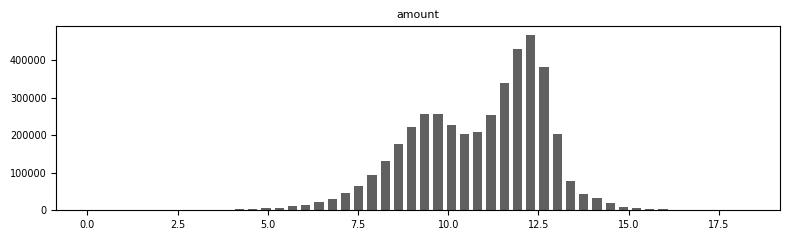

In [10]:
# More detailed look at amount distribution
plt.figure(figsize=(8, 2.5))
plt.hist(
    np.log1p(df_model['amount']),
    bins=50,
    color='#606060',
    rwidth=0.7
)

plt.title("amount", fontsize=8)
plt.xticks(fontsize=7)
plt.yticks(fontsize=7)

plt.tight_layout()
plt.show()

##### *Check multicollinearity*

<Axes: >

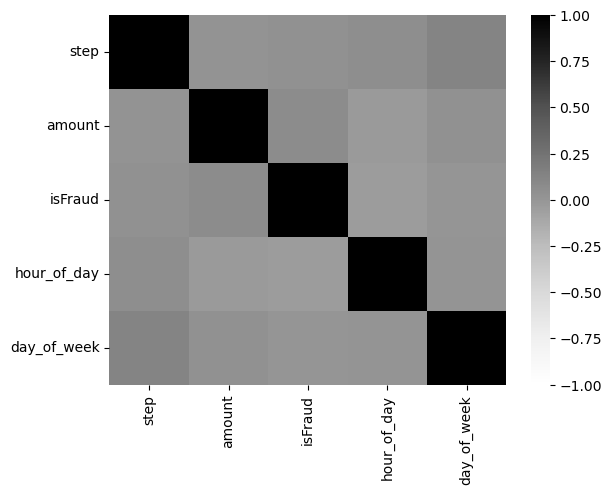

In [11]:
# Check for any features that might be explaining the same thing
import seaborn as sns
sns.heatmap(df_model.corr(numeric_only=True), vmin=-1, vmax=1, cmap="Greys")

#### III. Feature Engineering

##### *Create a feature engineering function*

In [12]:
def transform_fraud_data(df):
    df_model = df.copy()
    df_model = df_model.sort_values(["step", "amount"])

    # Flag repeating amounts in the same step
    df_model["is_repeating_amount"] = (
        df_model.groupby(["step", "amount"])["amount"]
                .transform("size") > 1
    ).astype(int)

    df_model = df_model.drop(
        ["step", "nameOrig", "nameDest"],
        axis=1,
        errors="ignore"
    )

    # One-hot encode payment types
    df_model = pd.get_dummies(df_model, dtype="int")

    return df_model

##### *Prepare datasets for modelling*

In [13]:
# Apply funtion to both datasets
df_training, df_testing = map(transform_fraud_data, [df_model, df_dashboard])

# Split features (X) and target (y)
X_train, y_train = df_training.drop("isFraud", axis=1), df_training["isFraud"]
X_test, y_test = df_testing.drop("isFraud", axis=1), df_testing["isFraud"]

# Save training dataset to Google Cloud Storage
for name, df in {"X_train": X_train, "y_train": y_train}.items():
    df.to_csv(
        f"gs://paysim_mobile_money/training_dataset/{name}.csv",
        index=False
    )

#### IV. Model Development

##### *Import libraries*

In [14]:
import gcsfs
import joblib
from google.cloud import aiplatform
from sklearn.metrics import roc_auc_score, confusion_matrix, recall_score, precision_score
from xgboost import XGBClassifier

#### *Model 1: Random Forest Classification*

##### *Train random forest model on Google Vertex AI*

In [ ]:
aiplatform.init(
    project="de-project-ecomm",
    location="asia-southeast1",
    staging_bucket="gs://paysim_mobile_money/staging_custom_jobs"
)

In [ ]:
job = aiplatform.CustomJob.from_local_script(
    display_name="fraud-rf-training",
    script_path="training_models/train_rf_model.py",
    container_uri="us-docker.pkg.dev/vertex-ai/training/sklearn-cpu.1-6:latest",
    requirements=["pandas", "scikit-learn", "joblib", "google-cloud-storage"],
    replica_count=1,
    machine_type="n2-standard-16"
)

job.run()

##### *Load the random forest model*

In [15]:
# Load the random forest model
fs = gcsfs.GCSFileSystem()

with fs.open("gs://paysim_mobile_money/models/random_forest_fraud_model.pkl", "rb") as f:
    best_rf = joblib.load(f)

/home/de_user/miniconda3/envs/onyx_env/lib/python3.11/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/de_user/miniconda3/envs/onyx_env/lib/python3.11/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


##### *Print Performance Metrics (ROC-AUC)*

In [16]:
y_train_proba = best_rf.predict_proba(X_train)[:, 1]
y_test_proba = best_rf.predict_proba(X_test)[:, 1]

print(f"Train ROC-AUC: {roc_auc_score(y_train, y_train_proba):.4f}")
print(f"Test ROC-AUC: {roc_auc_score(y_test, y_test_proba):.4f}")

Train ROC-AUC: 0.9875
Test ROC-AUC: 0.9674


#### Model 2: *XGboost Classification*

##### *Train xgboost model on Google Vertex AI*

In [ ]:
aiplatform.init(
    project="de-project-ecomm",
    location="asia-southeast1",
    staging_bucket="gs://paysim_mobile_money/staging_custom_jobs"
)

In [ ]:
job = aiplatform.CustomJob.from_local_script(
    display_name="fraud-xgb-training",
    script_path="training_models/train_xgb_model.py",
    container_uri="us-docker.pkg.dev/vertex-ai/training/sklearn-cpu.1-6:latest",
    requirements=["pandas", "scikit-learn==1.3.2", "joblib", "pyarrow", "google-cloud-storage", "xgboost==1.7.6"],
    replica_count=1,
    machine_type="n2-standard-16"
)

job.run()

##### *Load the xgboost classification model*

In [17]:
# Load the xgboost classification model
fs = gcsfs.GCSFileSystem()

local_path = "/tmp/xgboost_fraud_model.json"

with fs.open("gs://paysim_mobile_money/models/xgboost_fraud_model.json", "rb") as f:
    with open(local_path, "wb") as local_file:
        local_file.write(f.read())

best_xgb = XGBClassifier()
best_xgb.load_model(local_path)

##### *Print Performance Metrics (ROC-AUC)*

In [18]:
y_train_proba = best_xgb.predict_proba(X_train)[:, 1]
y_test_proba = best_xgb.predict_proba(X_test)[:, 1]

print(f"Train ROC-AUC: {roc_auc_score(y_train, y_train_proba):.4f}")
print(f"Test ROC-AUC: {roc_auc_score(y_test, y_test_proba):.4f}")

Train ROC-AUC: 0.9884
Test ROC-AUC: 0.9731


#### V. Evaluate Selected Model on Test Data

##### *Select Model*

**XGBoost** is the better model because it achieves a higher Test ROC-AUC (0.9731 vs 0.9674) and shows slightly better generalization with a smaller gap between Train and Test scores (0.9884 vs 0.9731). While Random Forest also performs strongly, its slightly lower Test performance and larger gap indicate marginally more overfitting. Therefore, XGBoost should be selected as the final model.

In [19]:
best_model = best_xgb

In [20]:
confusion_matrix(y_test, best_model.predict(X_test))

array([[2096225,     730],
       [   1165,    1545]])

In [21]:
recall_score(y_test, best_model.predict(X_test))

0.5701107011070111

In [22]:
precision_score(y_test, best_model.predict(X_test))

0.6791208791208792

#### VI. Threshold Tuning

In fraud detection, recall is prioritized to ensure that as many actual fraud cases as possible are identified, since missing fraud is highly costly. However, precision is still constrained to at least 20% to avoid an excessive number of false positives that could overwhelm fraud investigations. This approach balances strong fraud capture with a manageable level of false alarms.

##### *Import libraries*

In [23]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

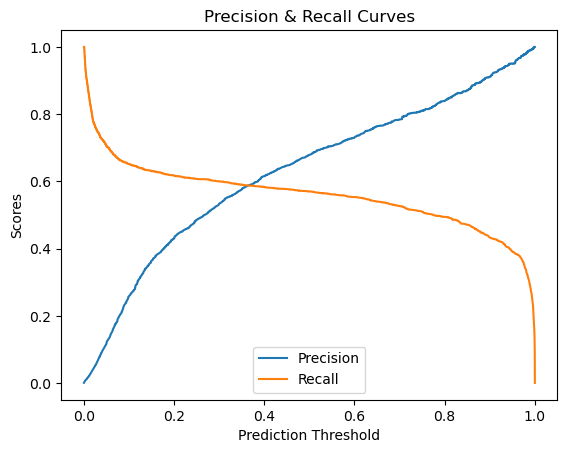

In [24]:
p_curve, r_curve, t_curve = precision_recall_curve(y_test, best_model.predict_proba(X_test)[:,1])

plt.plot(t_curve, p_curve[:-1], label='Precision')
plt.plot(t_curve, r_curve[:-1], label='Recall')
plt.xlabel('Prediction Threshold')
plt.ylabel('Scores')
plt.legend()
plt.title('Precision & Recall Curves')
plt.show()

In [25]:
# Precision constraint
valid_idx = np.where(p_curve[:-1] >= 0.2)[0]
threshold = t_curve[valid_idx[0]] 

# Identify threshold
threshold

np.float32(0.078531906)

In [26]:
confusion_matrix(y_test, best_model.predict_proba(X_test)[:,1] > threshold)

array([[2089749,    7206],
       [    908,    1802]])

In [27]:
recall_score(y_test, best_model.predict_proba(X_test)[:,1] > threshold)

0.6649446494464945

In [28]:
precision_score(y_test, best_model.predict_proba(X_test)[:,1] > threshold)

0.20004440497335702

#### VII. Batch Inference

##### *Label batch input data*

In [29]:
# Sort df_dashboard the same way batch input data is sorted
df_dashboard = df_dashboard.sort_values(["step", "amount"])

# Add predictions as new column
df_dashboard["FraudProbability"] = best_model.predict_proba(X_test)[:, 1]
df_dashboard["isFlaggedFraud"] = (df_dashboard["FraudProbability"] > threshold).astype(int)

# Preview results
df_dashboard.head()

,step,type,amount,nameOrig,nameDest,isFraud,hour_of_day,day_of_week,FraudProbability,isFlaggedFraud
2450,1,PAYMENT,6.93,C730584984,M1276666395,0,1,0,0.000002,0
2447,1,PAYMENT,13.54,C1172417096,M314966354,0,1,0,0.000002,0
753,1,PAYMENT,15.06,C1730337646,M418513504,0,1,0,0.000002,0
2092,1,PAYMENT,53.35,C1908999587,M816804727,0,1,0,0.000002,0
1807,1,PAYMENT,79.26,C2034975583,M955443582,0,1,0,0.000002,0


#### VIII. Feature Importance

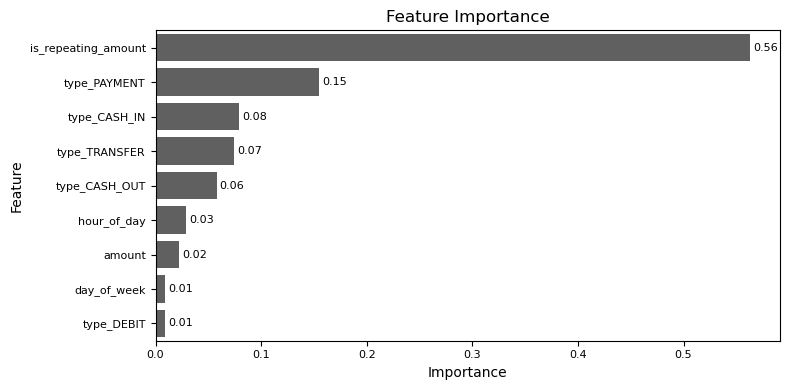

In [30]:
importance = pd.DataFrame({
    "feature": X_test.columns,
    "importance": best_model.feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(8, 4))

ax = sns.barplot(
    data=importance,
    x="importance",
    y="feature",
    color="#606060"
)

ax.set_title("Feature Importance", fontsize=12)
ax.set_xlabel("Importance", fontsize=10)
ax.set_ylabel("Feature", fontsize=10)

ax.tick_params(axis='both', labelsize=8)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", fontsize=8, padding=2)

plt.tight_layout()
plt.show()

### Save Results

##### *PostgreSQL database set-up*

In [31]:
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine

In [32]:
# Load then read database credentials
load_dotenv()

DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")

# Create a postgreSQL connection engine
engine = create_engine(
    f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

##### *Save labeled dataset*

In [33]:
df_dashboard.to_sql(
    name="labeled_dataset",
    con=engine,
    schema="public",
    if_exists="replace",
    index=False,
)

665

In [34]:
importance.to_sql(
    name="feature_importance",
    con=engine,
    schema="public",
    if_exists="replace",
    index=False,
)

9

### --End--